This code bootstraps wind data by cluster

In [1]:
import numpy as np
import pandas as pd, os, datetime
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Statistical analysis
from typing import Sequence, Tuple, Optional
from joblib import Parallel, delayed
from scipy import stats
import math

# Plottting
import matplotlib.pyplot as plt

# Import the loader function
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')
from process_code import load_generation_data

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that i

Dask dashboard: /proxy/8787/status


2026-01-21 12:53:01,072 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle cee544f46277e03a913ec0f30b38a86e initialized by task ('shuffle-transfer-cee544f46277e03a913ec0f30b38a86e', 2) executed on worker tcp://127.0.0.1:46643
2026-01-21 12:53:09,504 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle cee544f46277e03a913ec0f30b38a86e deactivated due to stimulus 'task-finished-1768960389.49051'
2026-01-21 12:53:10,639 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle d2bf34415c6f40f73dd94d7619c24bee initialized by task ('shuffle-transfer-d2bf34415c6f40f73dd94d7619c24bee', 0) executed on worker tcp://127.0.0.1:34543
2026-01-21 12:53:13,818 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle d2bf34415c6f40f73dd94d7619c24bee deactivated due to stimulus 'task-finished-1768960393.5165272'


In [2]:
clust_map = pd.read_csv("data/preprocess/wind_spatial_clusters.csv")

In [3]:
data, info = load_generation_data(
    sdate="2009-07-01",
    edate="2024-06-30",
    mode="hourly",
    ftype=["Wind"],
    apply_remove_negatives=True,
    apply_remove_wind_zeros=True,
    apply_min_heatwave_days=True,
    min_heatwave_days_threshold=20,
    apply_clear_agc=False
)

Read gen_details & hw_tseries with Dask: 0.21 sec
Select group: 0.01 sec
--- Starting Dask-Native Process ---


/g/data/ng72/ms5578/ID_HW_BARRA/process_code.py:168: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp_pd_jittered = grp_pd.groupby(['lat', 'lon'], group_keys=False).apply(


Starting final Dask compute...
Dask compute finished.

--- DASK TIMING REPORT ---
duid_setup: 0.00 seconds
csv_bulk_read: 1.06 seconds
filter_and_clean: 0.02 seconds
type_conversion_and_dropna: 0.03 seconds
date_filter: 0.01 seconds
hw_tseries_filter: 9.04 seconds
aggregate_hourly: 0.03 seconds
jitter: 0.26 seconds
final_merge: 0.03 seconds
compute: 73.81 seconds
--- END REPORT ---

Process group: 88.38 sec

--- DEBUG: Calculated Heatwave Days per Generator ---
DUID
MUSSELR1    334
SAPHWF1     206
WRWF1       201
HALLWF2     187
HALLWF1     187
GUNNING1    178
WOODLWN1    171
LKBONNY2    168
GULLRWF1    164
NBHWF1      162
WATERLWF    161
CLEMGPWF    158
SNOWTWN1    157
LKBONNY3    157
BLUFF1      151
TARALGA1    150
MEWF1       143
BOCORWF1    126
BODWF1      122
STWF1       115
SNOWNTH1    109
OAKLAND1    108
COOPGWF1    103
BALDHWF1    101
MACARTH1     98
HDWF1        98
HDWF2        92
HDWF3        92
SNOWSTH1     89
MERCER01     84
GRANWF1      84
CROOKWF2     76
ARWF1        72
K

Append clusters to generation timeseries in tidy format

In [4]:
df = pd.merge(data,clust_map[['DUID','cluster','cluster_name','cluster_color']], on='DUID').sort_values(['EHF_flag','cluster','DUID','time'])

Z-score normalise by cluster.

In [5]:
df['z_score'] = df.groupby('DUID')['TOTALMWh'].transform(
    lambda x: (x - x.mean()) / x.std(ddof=1)
)
df

,DUID,time,TOTALMWh,TOTALCLEARED,AGCSTATUS,lat,lon,tas,EHF_val,HW_EHF_avg,...,HW_event_day,date,fuel_source_primary,region,lat_jittered,lon_jittered,cluster,cluster_name,cluster_color,z_score
293522,BOCORWF1,2014-08-29 02:00:00+00:00,0.0,0.0,0,-36.63,149.09,279.182373,0.000000,NaN,...,NaN,2014-08-29 00:00:00+00:00,Wind,NSW1,-36.578900,149.162452,0,Alpine NSW,#e78ac3,-0.92126
293523,BOCORWF1,2014-08-29 03:00:00+00:00,0.000833,0.0,0,-36.63,149.09,279.182373,0.000000,NaN,...,NaN,2014-08-29 00:00:00+00:00,Wind,NSW1,-36.578900,149.162452,0,Alpine NSW,#e78ac3,-0.921242
293524,BOCORWF1,2014-08-29 04:00:00+00:00,0.0,0.0,0,-36.63,149.09,279.182373,0.000000,NaN,...,NaN,2014-08-29 00:00:00+00:00,Wind,NSW1,-36.578900,149.162452,0,Alpine NSW,#e78ac3,-0.92126
293525,BOCORWF1,2014-08-29 05:00:00+00:00,0.0,0.0,0,-36.63,149.09,279.182373,0.000000,NaN,...,NaN,2014-08-29 00:00:00+00:00,Wind,NSW1,-36.578900,149.162452,0,Alpine NSW,#e78ac3,-0.92126
293526,BOCORWF1,2014-08-29 07:00:00+00:00,0.0,0.0,0,-36.63,149.09,279.182373,0.000000,NaN,...,NaN,2014-08-29 00:00:00+00:00,Wind,NSW1,-36.578900,149.162452,0,Alpine NSW,#e78ac3,-0.92126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2382330,MUSSELR1,2024-03-13 19:00:00+00:00,49.383334,49.341667,0,-40.81,147.99,288.553955,0.065206,4.584469,...,5.0,2024-03-13 00:00:00+00:00,Wind,TAS1,-40.779811,148.009739,5,Bass Strait,#66c2a5,-0.299817
2382331,MUSSELR1,2024-03-13 20:00:00+00:00,24.341667,24.625,0,-40.81,147.99,288.553955,0.065206,4.584469,...,5.0,2024-03-13 00:00:00+00:00,Wind,TAS1,-40.779811,148.009739,5,Bass Strait,#66c2a5,-0.686428
2382332,MUSSELR1,2024-03-13 21:00:00+00:00,4.725,4.875,0,-40.81,147.99,288.553955,0.065206,4.584469,...,5.0,2024-03-13 00:00:00+00:00,Wind,TAS1,-40.779811,148.009739,5,Bass Strait,#66c2a5,-0.989283
2382333,MUSSELR1,2024-03-13 22:00:00+00:00,0.0,0.0,0,-40.81,147.99,288.553955,0.065206,4.584469,...,5.0,2024-03-13 00:00:00+00:00,Wind,TAS1,-40.779811,148.009739,5,Bass Strait,#66c2a5,-1.062231


In [6]:
def bootstrap_curve(
    X: np.ndarray,
    n_boot: int,
    batch_size: Optional[int] = None,
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Bootstrap mean and median daily curves with confidence intervals, batched for speed and memory.

    Parameters
    ----------
    X : np.ndarray
        Array of shape (n_days, n_hours)
    n_boot : int
        Number of bootstrap samples
    batch_size : Optional[int]
        Number of bootstrap samples to process per batch. If None, chosen automatically.
    seed : int
        RNG seed for reproducibility

    Returns
    -------
    mean_curve : np.ndarray, shape (n_hours,)
    mean_lower : np.ndarray, shape (n_hours,)
    mean_upper : np.ndarray, shape (n_hours,)
    median_curve : np.ndarray, shape (n_hours,)
    median_lower : np.ndarray, shape (n_hours,)
    median_upper : np.ndarray, shape (n_hours,)
    """
    n_days, n_hours = X.shape
    curves_mean = np.empty((n_boot, n_hours), dtype=np.float64)
    curves_median = np.empty((n_boot, n_hours), dtype=np.float64)
    rng = np.random.default_rng(seed)

    # Choose a batch size that keeps memory reasonable
    if batch_size is None:
        # Aim for ~50–200 MB peak for the 3D array; adjust as needed
        # Each float64 ~8 bytes -> batch_size * n_days * n_hours * 8 bytes
        target_bytes = 100 * 1024 * 1024  # 100 MB
        approx_bs = max(1, int(target_bytes / (n_days * n_hours * 8)))
        batch_size = min(n_boot, max(100, approx_bs))

    out_start = 0
    while out_start < n_boot:
        k = min(batch_size, n_boot - out_start)
        # Indices: shape (k, n_days)
        idx = rng.integers(0, n_days, size=(k, n_days))
        # Samples: shape (k, n_days, n_hours)
        samples = X[idx]
        # Aggregate across days -> shape (k, n_hours)
        curves_mean[out_start:out_start + k] = samples.mean(axis=1)
        curves_median[out_start:out_start + k] = np.median(samples, axis=1)
        out_start += k

    # Compute mean and 95% CI across bootstrap replicates
    mean_curve = curves_mean.mean(axis=0)
    mean_lower = np.percentile(curves_mean, 2.5, axis=0)
    mean_upper = np.percentile(curves_mean, 97.5, axis=0)

    # Median curve is the median across bootstrap medians
    median_curve = np.median(curves_median, axis=0)
    median_lower = np.percentile(curves_median, 2.5, axis=0)
    median_upper = np.percentile(curves_median, 97.5, axis=0)

    return mean_curve, mean_lower, mean_upper, median_curve, median_lower, median_upper

In [7]:
def prepare_daily_matrix(
    df: pd.DataFrame,
    value_col: str,
    time_col: str = "time",
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Convert a long time series into a (n_days, n_hours) matrix and hour labels.
    Returns:
        X : ndarray shape (n_days, n_hours)
        hours : ndarray of hour labels (e.g. 0..23)
    """
    if df.empty:
        return np.empty((0, 0)), np.array([], dtype=int)

    tmp = df.copy()
    tmp["day"] = tmp[time_col].dt.floor("D")
    tmp["hour"] = tmp[time_col].dt.hour

    daily = (
        tmp.pivot_table(index="day", columns="hour", values=value_col)
           .dropna()
           .sort_index()
    )

    if daily.empty:
        return np.empty((0, 0)), np.array(sorted(tmp["hour"].unique()), dtype=int)

    X = daily.to_numpy()
    hours = daily.columns.to_numpy()
    return X, hours

In [8]:
def bootstrap_group(
    name,
    gdf: pd.DataFrame,
    value_col: str = "z_score",
    n_boot: int = 1000,
    batch_size: Optional[int] = None,
    seed: int = 42,
):
    """
    Apply bootstrap_curve to a single group.
    Returns:
        group key (name), curves tuple, hour_labels (array)
    """
    X, hour_labels = prepare_daily_matrix(gdf, value_col=value_col, time_col="time")

    # Handle groups with no valid days
    if X.size == 0 or X.shape[0] == 0:
        n_hours = len(hour_labels)
        empty = np.full(n_hours, np.nan)
        return name, (empty, empty, empty, empty, empty, empty), hour_labels

    curves = bootstrap_curve(X, n_boot=n_boot, batch_size=batch_size, seed=seed)
    return name, curves, hour_labels

In [9]:
def _results_to_dataframe(
    results,
    group_cols: Sequence[str],
) -> pd.DataFrame:
    """
    Convert list of (name, curves, hour_labels) into a tidy DataFrame.
    """
    rows = []
    for name, curves, hour_labels in results:
        mean_curve, mean_lower, mean_upper, median_curve, median_lower, median_upper = curves

        if isinstance(name, tuple):
            key_map = dict(zip(group_cols, name))
        else:
            key_map = {group_cols[0]: name}

        for i, hour in enumerate(hour_labels):
            rows.append(
                {
                    **key_map,
                    "hour": int(hour),
                    "mean": float(mean_curve[i]) if np.isfinite(mean_curve[i]) else np.nan,
                    "mean_lower": float(mean_lower[i]) if np.isfinite(mean_lower[i]) else np.nan,
                    "mean_upper": float(mean_upper[i]) if np.isfinite(mean_upper[i]) else np.nan,
                    "median": float(median_curve[i]) if np.isfinite(median_curve[i]) else np.nan,
                    "median_lower": float(median_lower[i]) if np.isfinite(median_lower[i]) else np.nan,
                    "median_upper": float(median_upper[i]) if np.isfinite(median_upper[i]) else np.nan,
                }
            )
    return pd.DataFrame(rows)

In [10]:
def run_grouped_bootstrap(
    df: pd.DataFrame,
    value_col: str = "z_score",
    n_boot: int = 1000,
    group_cols: Sequence[str] = ("cluster", "DUID", "EHF_flag"),
    parallel: bool = True,
    n_jobs: int = -1,
    backend: str = "loky",
    prefer: Optional[str] = None,
    batch_size: Optional[int] = None,
    seed: int = 42,
) -> pd.DataFrame:
    """
    High-level function to compute bootstrapped curves by group.

    Parameters
    ----------
    df : DataFrame
        Must contain `time`, `value_col`, and `group_cols`.
    parallel : bool
        If True, use joblib.Parallel; otherwise run in a single process.
    """
    needed = set(group_cols) | {"time", value_col}
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    grouped = df.groupby(list(group_cols), sort=False)

    if parallel:
        tasks = (
            delayed(bootstrap_group)(
                name,
                gdf,
                value_col=value_col,
                n_boot=n_boot,
                batch_size=batch_size,
                seed=seed,
            )
            for name, gdf in grouped
        )

        results = Parallel(n_jobs=n_jobs, backend=backend, prefer=prefer)(tasks)
    else:
        results = [
            bootstrap_group(
                name,
                gdf,
                value_col=value_col,
                n_boot=n_boot,
                batch_size=batch_size,
                seed=seed,
            )
            for name, gdf in grouped
        ]

    return _results_to_dataframe(results, group_cols)

Here is where the grouping, value, and number of bootstraps is specified.

In [11]:
df_results = run_grouped_bootstrap(
    df,
    value_col="z_score",
    n_boot=10000,
    group_cols=("cluster", "EHF_flag"),
    parallel=True,
    n_jobs=-1,
    backend="loky",
)

In [12]:
df_results = df_results.merge(clust_map[["cluster","cluster_name","cluster_color"]], on="cluster", how='left')

In [13]:
df_results

,cluster,EHF_flag,hour,mean,mean_lower,mean_upper,median,median_lower,median_upper,cluster_name,cluster_color
0,0,0.0,0,-0.014003,-0.036347,0.008666,-0.177602,-0.200642,-0.151143,Alpine NSW,#e78ac3
1,0,0.0,0,-0.014003,-0.036347,0.008666,-0.177602,-0.200642,-0.151143,Alpine NSW,#e78ac3
2,0,0.0,0,-0.014003,-0.036347,0.008666,-0.177602,-0.200642,-0.151143,Alpine NSW,#e78ac3
3,0,0.0,0,-0.014003,-0.036347,0.008666,-0.177602,-0.200642,-0.151143,Alpine NSW,#e78ac3
4,0,0.0,0,-0.014003,-0.036347,0.008666,-0.177602,-0.200642,-0.151143,Alpine NSW,#e78ac3
...,...,...,...,...,...,...,...,...,...,...,...
2635,5,1.0,22,-0.152179,-0.233192,-0.068797,-0.349766,-0.450242,-0.244730,Bass Strait,#66c2a5
2636,5,1.0,23,-0.170405,-0.253097,-0.084604,-0.396346,-0.471538,-0.249069,Bass Strait,#66c2a5
2637,5,1.0,23,-0.170405,-0.253097,-0.084604,-0.396346,-0.471538,-0.249069,Bass Strait,#66c2a5
2638,5,1.0,23,-0.170405,-0.253097,-0.084604,-0.396346,-0.471538,-0.249069,Bass Strait,#66c2a5


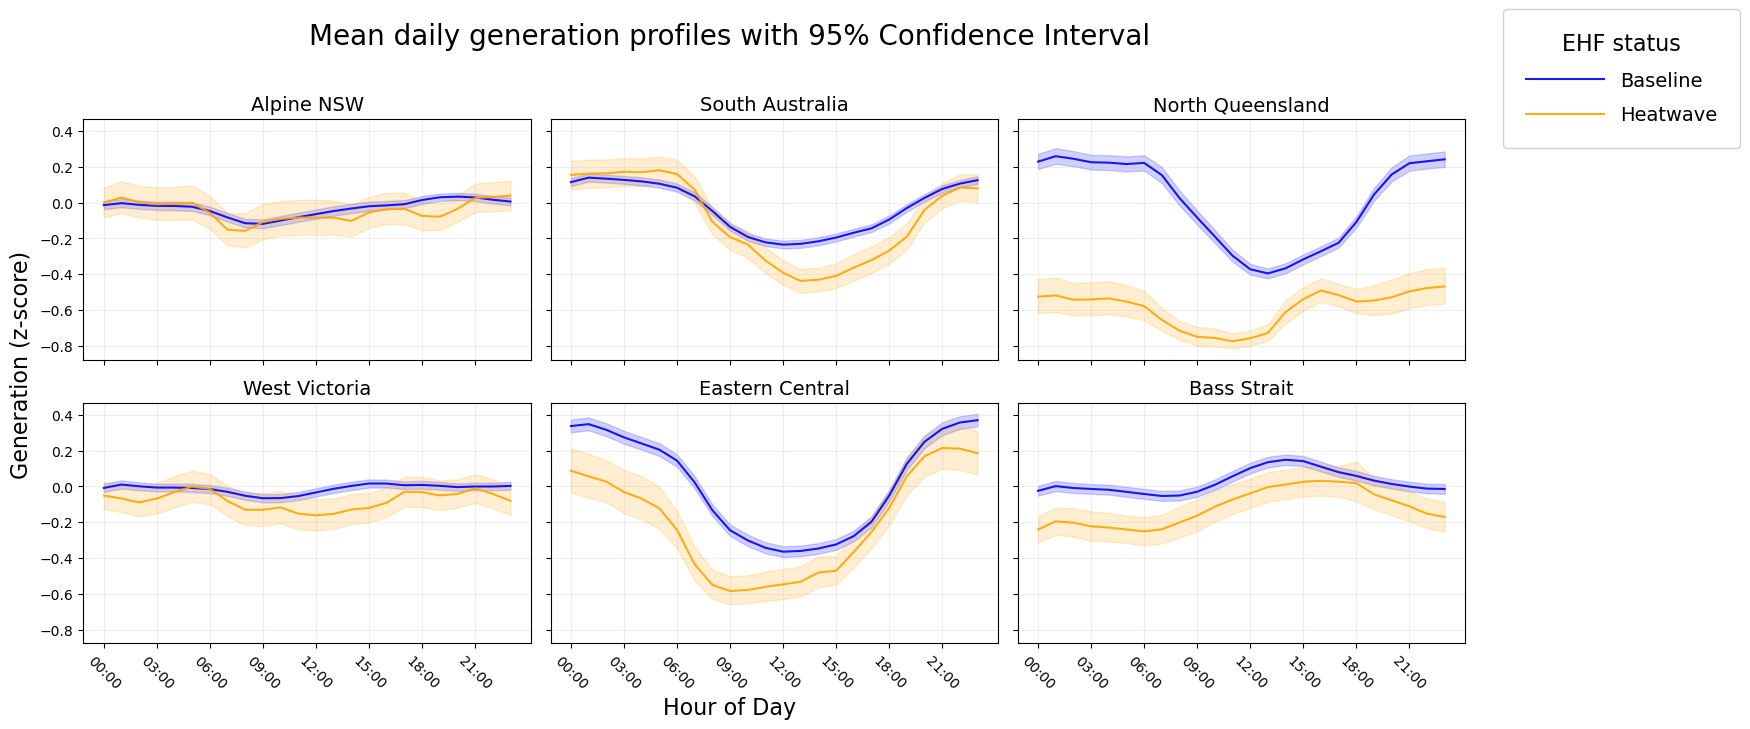

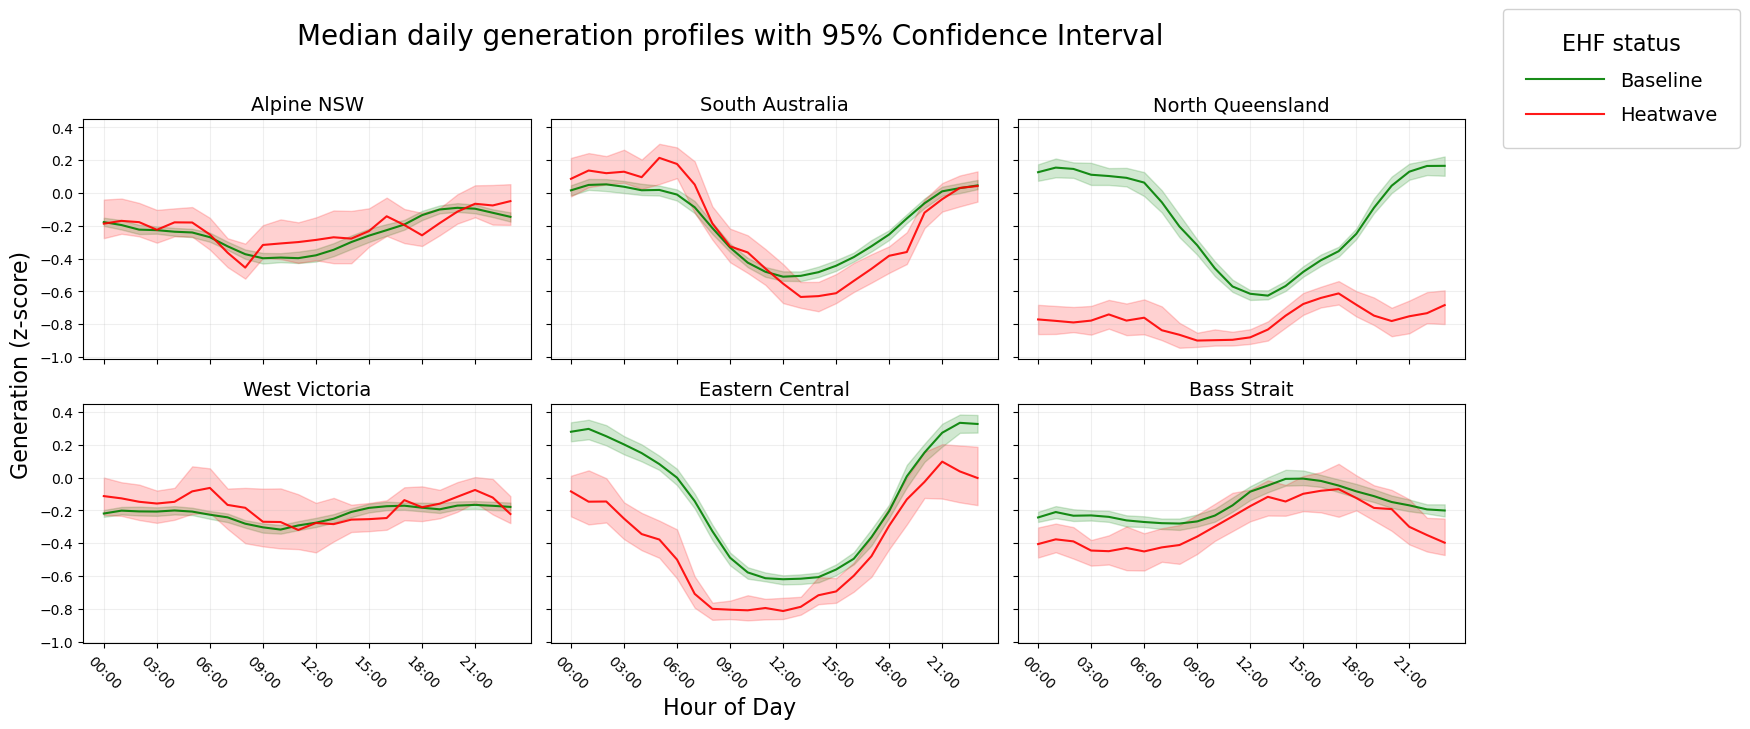

In [14]:
def plot_aggregated_clusters_faceted(df_results: pd.DataFrame, metric='mean'):
    """
    Plot mean/median curves with 95% CI for aggregated clusters in a 2x3 faceted layout.
    """

    if metric not in ['mean', 'median']:
        raise ValueError("metric must be 'mean' or 'median'")

    clusters = sorted(df_results['cluster'].unique())
    # map numeric cluster -> new descriptive cluster_name
    name_map = (
        df_results[['cluster', 'cluster_name']]
        .drop_duplicates()
        .set_index('cluster')['cluster_name']
        .to_dict()
    )

    if len(clusters) == 0:
        raise ValueError("No clusters found in df_results")

    nrows, ncols = 2, 3
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(5*ncols, 3.8*nrows),
                             sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    label_map = {0.0: "Baseline", 1.0: "Heatwave"}
    label_map_int = {0: "Baseline", 1: "Heatwave"}
    colors = ['blue', 'orange'] if metric == "mean" else ['green', 'red']

    hour_ticks = list(range(0,24,3))
    hour_labels = [f"{h:02d}:00" for h in hour_ticks]

    # Plot each aggregated cluster in its own facet
    for ax_idx, cluster in enumerate(clusters[:nrows*ncols]):
        ax = axes[ax_idx]
        cdf = df_results[df_results['cluster'] == cluster].copy()
        hw_statuses = sorted(cdf['EHF_flag'].unique())

        for i, status in enumerate(hw_statuses):
            sdf = cdf[cdf['EHF_flag'] == status].sort_values('hour')

            y = sdf[metric].values
            lower = sdf[f'{metric}_lower'].values
            upper = sdf[f'{metric}_upper'].values

            label = label_map.get(float(status), label_map_int.get(int(status), str(status)))
            ax.plot(sdf['hour'], y, color=colors[i % len(colors)], alpha=0.9, label=label)
            ax.fill_between(sdf['hour'], lower, upper, color=colors[i % len(colors)], alpha=0.18)

        # use the human-readable cluster name
        pretty_name = name_map.get(cluster, f"Cluster {cluster}")
        ax.set_title(pretty_name, fontsize=14)

        ax.set_xticks(hour_ticks)
        ax.set_xticklabels(hour_labels, rotation=315)

        ax.grid(True, alpha=0.2)

    # Remove unused axes
    for ax in axes[len(clusters):]:
        ax.remove()

    fig.suptitle(f'{metric.capitalize()} daily generation profiles with 95% Confidence Interval', y=0.95, fontsize=20)
    fig.text(0.5, 0.04, 'Hour of Day', ha='center', fontsize=16)
    fig.text(0.02, 0.5, 'Generation (z-score)', va='center', rotation='vertical', fontsize=16)

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    seen = set()
    uniq = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
    if uniq:
        fig.legend(
        [h for h, _ in uniq],
        [l for _, l in uniq],
        title="EHF status",
        loc='upper right',
        bbox_to_anchor=(1.18, 0.98),
    
        # --- NEW: make legend bigger ---
        prop={'size': 14},         # legend text size
        title_fontsize=16,         # legend title size
    
        # --- NEW: make the panel larger & clearer ---
        frameon=True,              # draw a box around legend
        framealpha=0.9,            # panel transparency
        borderpad=1.2,             # padding inside the panel
        labelspacing=0.8,          # spacing between items
        handlelength=4,          # length of color lines
    )


    plt.tight_layout(rect=[0.03, 0.05, 1, 0.93])
    plt.show()

# Example:
plot_aggregated_clusters_faceted(df_results, metric='mean')
plot_aggregated_clusters_faceted(df_results, metric='median')
